In [1]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import healpy as hp
import pysm3.units as u

def find_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / '.git').exists():
            return p
    return start

root = find_root()
os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
print('Root:', root)

Root: /home/julian/Documents/cmb-sbi-inference


In [2]:
from src.simulation.factories import SimulatorFactory

sim = SimulatorFactory.get_simulator('d1s1_skymap')
nside, lmax = sim.nside, sim.lmax
print(f'nside={nside}  lmax={lmax}')
print('Frequencies:', sim.frequencies)

r = 0.05
A_d, beta_d = 1.0, 1.54
A_s, beta_s = 1.0, -3.0
params = torch.tensor([r, A_d, beta_d, A_s, beta_s])
print('params:', params.tolist())

/home/julian/miniconda3/envs/sbi_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


nside=32  lmax=96
Frequencies: [27, 39, 93, 145, 225, 280]
params: [0.05000000074505806, 1.0, 1.5399999618530273, 1.0, -3.0]


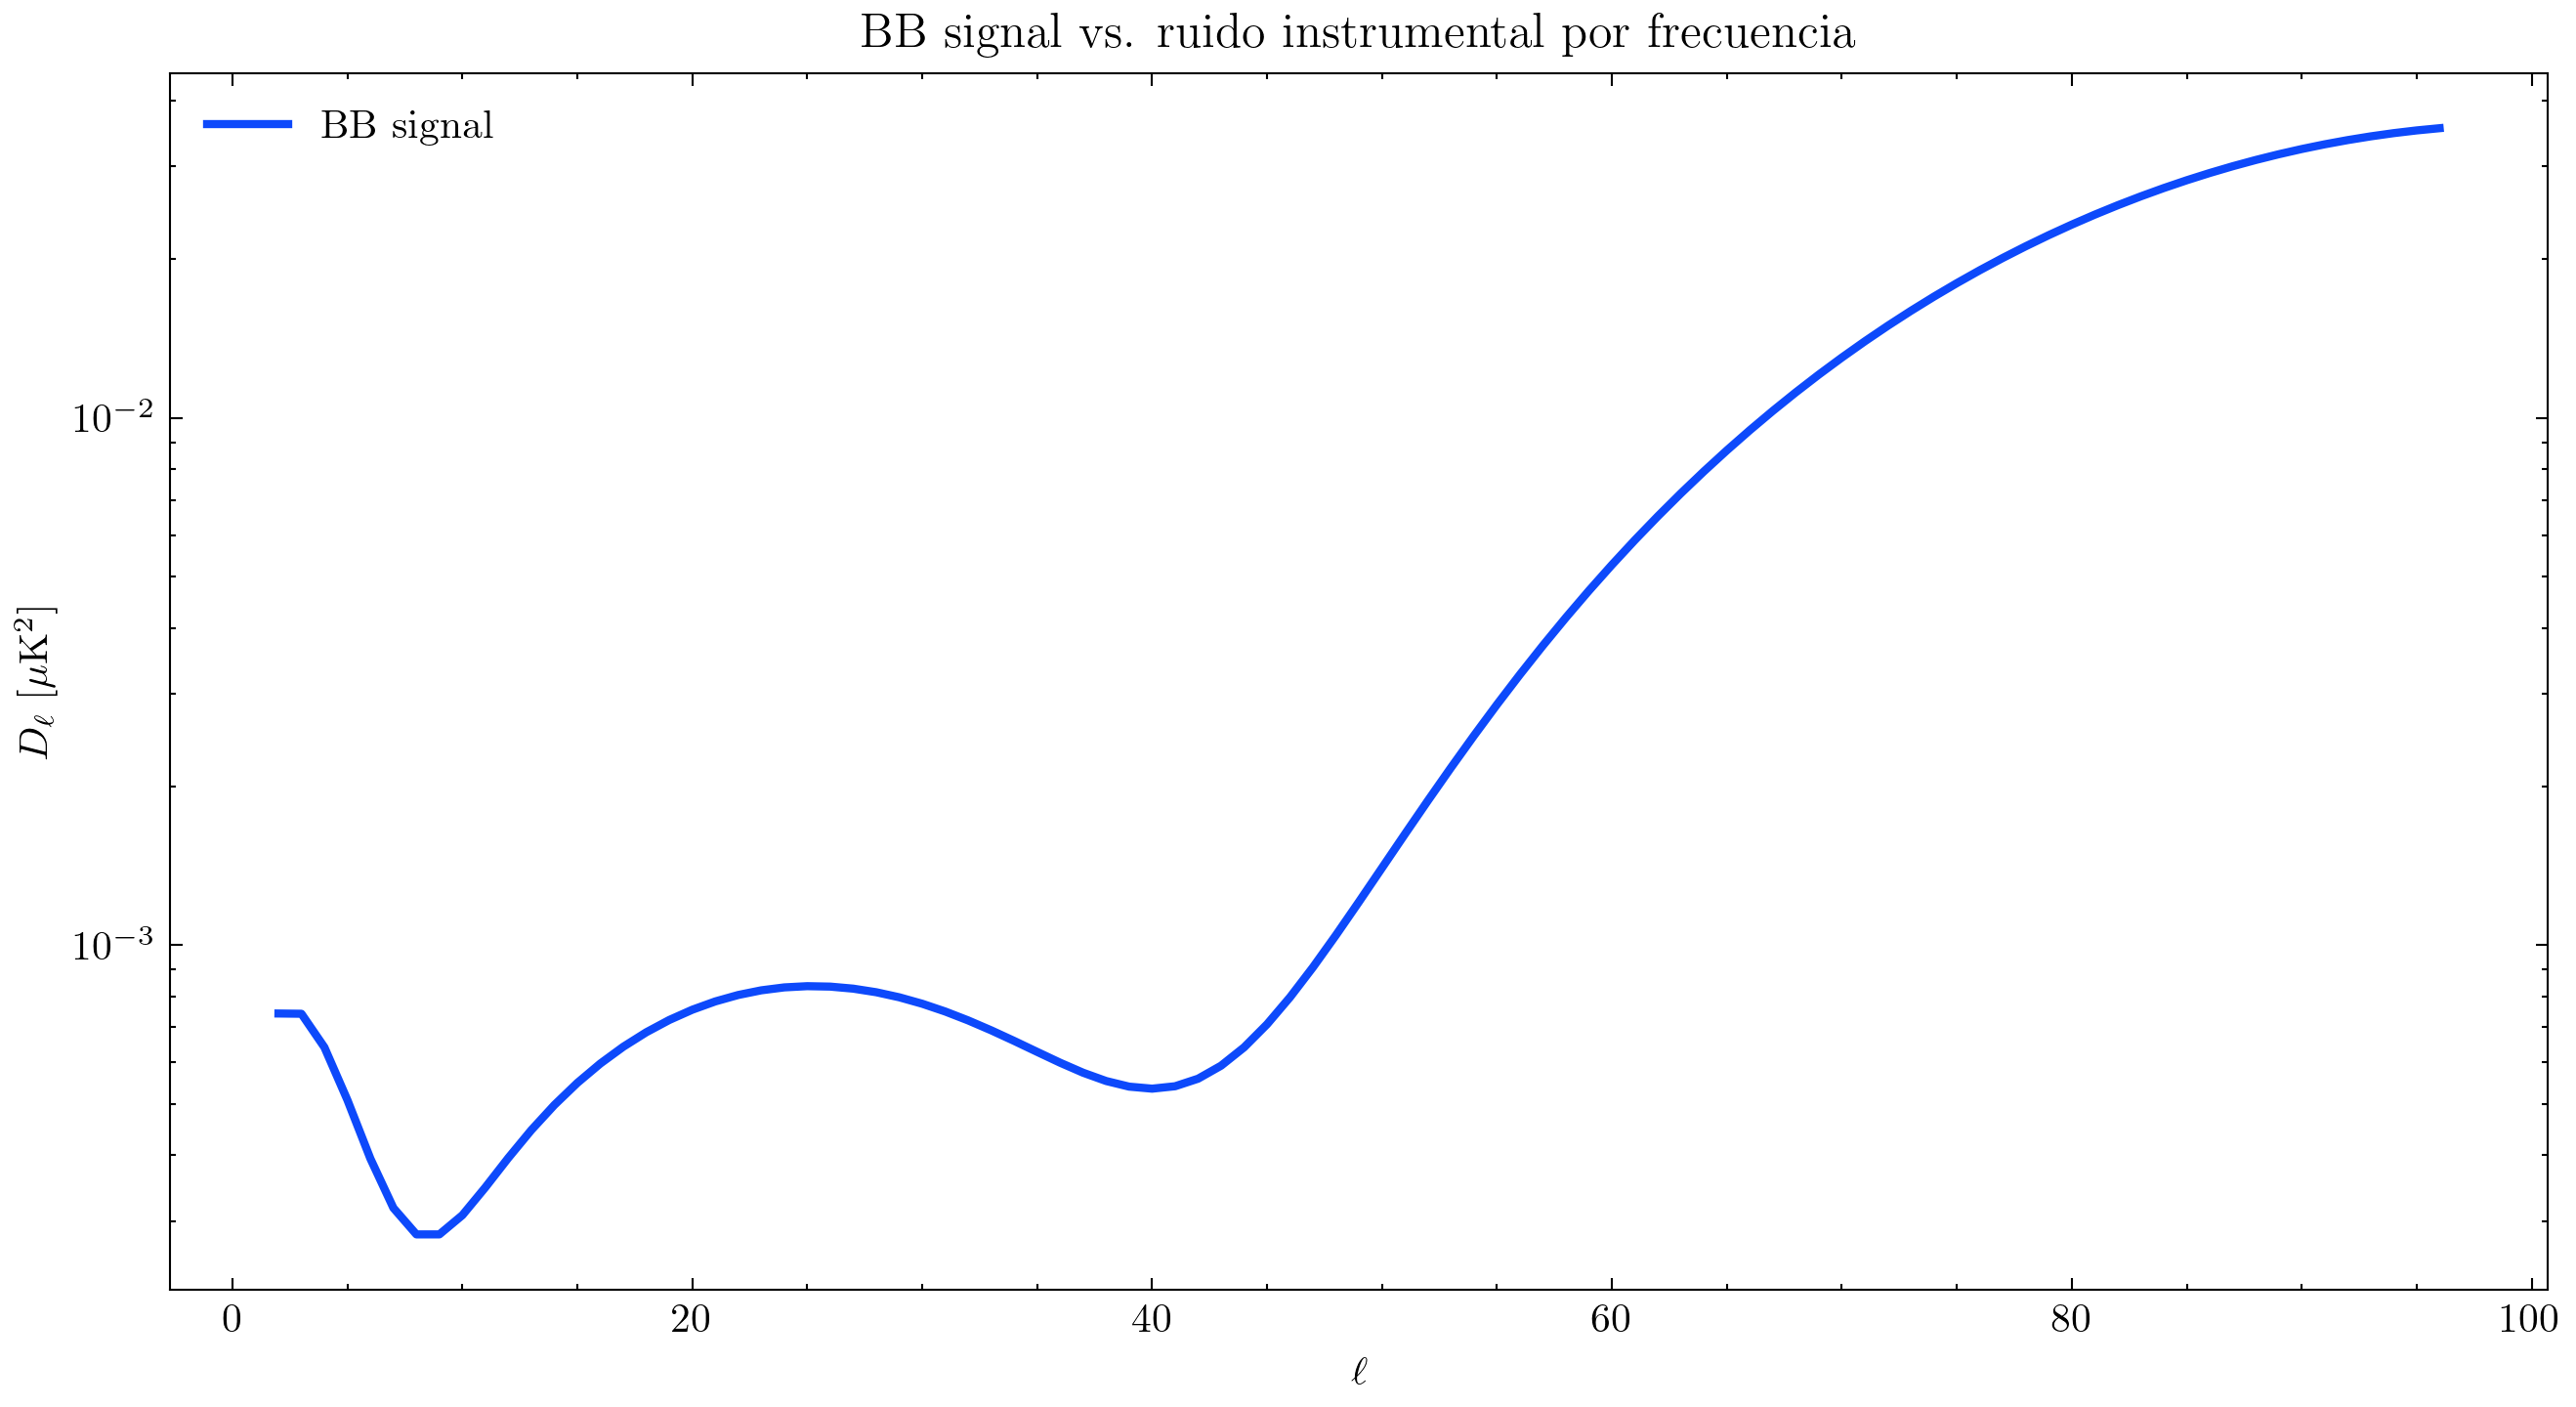

In [3]:
ell = np.arange(lmax + 1)
cl_theory = sim._get_theory_cl_bb(r)
dl_theory = ell * (ell + 1) * cl_theory[:len(ell)] / (2 * np.pi)

plt.figure(figsize=(9, 5))
plt.plot(ell[2:], dl_theory[2:], lw=2, label='BB signal')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell\;[\mu\mathrm{K}^2]$')
plt.title('BB signal vs. ruido instrumental por frecuencia')
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

CMB Q  std=7.662e-02   U  std=7.716e-02


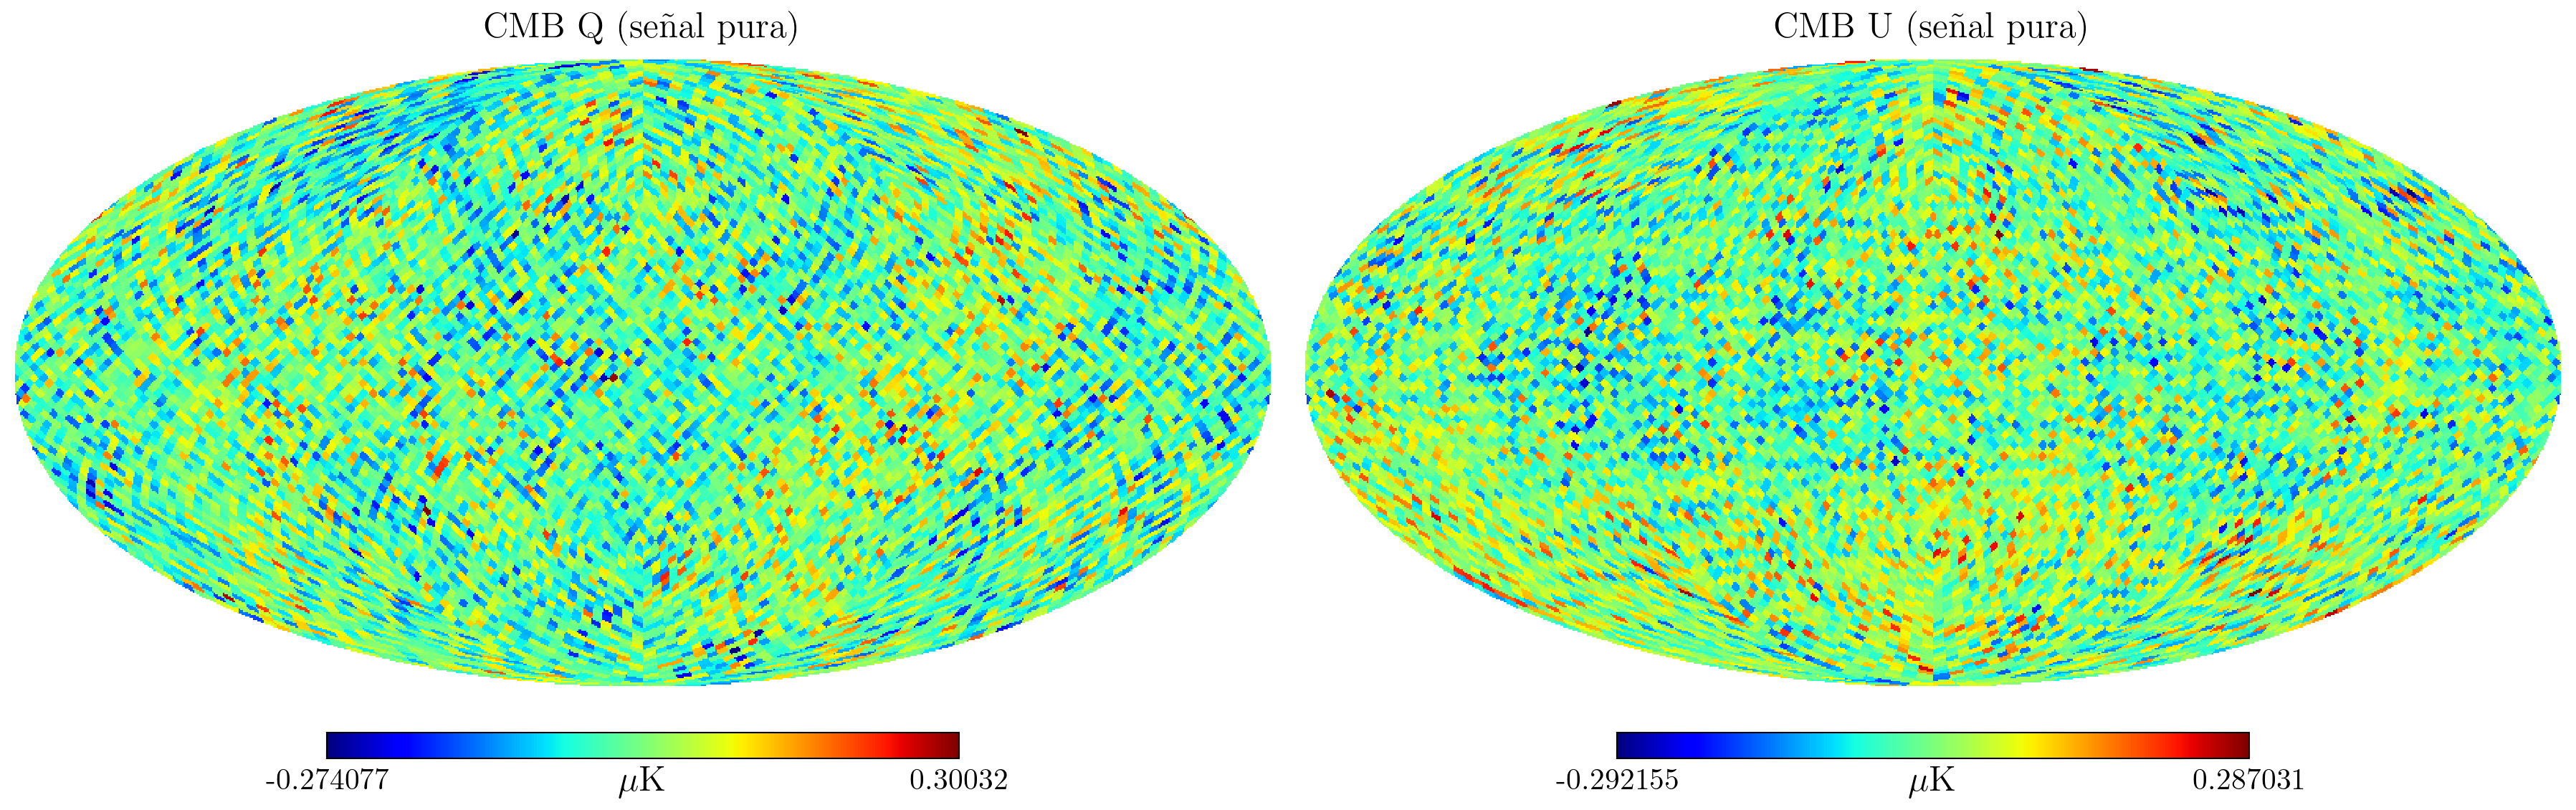

In [4]:
alm_e_cmb, alm_b_cmb = sim._generate_cmb_alms(r)
q_cmb, u_cmb = sim._alm2map(alm_e_cmb, alm_b_cmb)
print(f'CMB Q  std={np.std(q_cmb):.3e}   U  std={np.std(u_cmb):.3e}')

plt.figure(figsize=(12, 4))
hp.mollview(q_cmb, title='CMB Q (señal pura)', unit=r'$\mu$K', cmap='jet', sub=(1, 2, 1))
hp.mollview(u_cmb, title='CMB U (señal pura)', unit=r'$\mu$K', cmap='jet', sub=(1, 2, 2))
plt.show()

In [5]:
# n_f = len(sim.frequencies)
# sim._update_foreground_parameters(beta_d, beta_s)
# plt.figure(figsize=(12, 4 * n_f))
# for i, nu in enumerate(sim.frequencies):
#     alm_e_fg, alm_b_fg = sim._get_foreground_alms(nu, A_d, A_s)
#     q_fg, u_fg = sim._alm2map(alm_e_fg, alm_b_fg)
#     hp.mollview(q_fg, sub=(n_f, 2, 2*i+1), title=f'FG Q @ {nu} GHz', unit=r'$\mu$K', cmap='jet')
#     hp.mollview(u_fg, sub=(n_f, 2, 2*i+2), title=f'FG U @ {nu} GHz', unit=r'$\mu$K', cmap='jet')
# plt.tight_layout()
# plt.show()

In [6]:
import time
start = time.time()
freq_maps = sim.simulate(params)
end = time.time()

print('Output shape (freqs, Q/U, pix):', tuple(freq_maps.shape))
print(f'Tiempo de simulación: {end - start:.3f} s')

Output shape (freqs, Q/U, pix): (6, 2, 12288)
Tiempo de simulación: 5.595 s


In [ ]:
from src.simulation.factories import PriorFactory
prior = PriorFactory.get_prior('pol').to_sbi()

In [16]:
theta, x = sim.simulate_batch(
    num_simulations=10,
    prior=prior,
    seed=1,
    num_workers=1
)

100%|██████████| 10/10 [00:05<00:00,  1.82it/s]


In [18]:
print(theta.shape, x.shape)

torch.Size([10, 5]) torch.Size([10, 6, 2, 12288])


In [8]:
# plt.figure(figsize=(12, 4 * n_f))
# for i, nu in enumerate(sim.frequencies):
#     q_obs_s1 = freq_maps[i, 0].numpy()   
#     u_obs_s1 = freq_maps[i, 1].numpy()  
#     hp.mollview(q_obs_s1, sub=(n_f, 2, 2*i+1), title=f'Obs Q @ {nu} GHz', unit=r'$\mu$K', cmap='jet')
#     hp.mollview(u_obs_s1, sub=(n_f, 2, 2*i+2), title=f'Obs U @ {nu} GHz', unit=r'$\mu$K', cmap='jet')
# plt.tight_layout()
# plt.show()